# Complaint Severity Score Classification

**The following information was added to add structure to the project**

## Project Overview
The organisation must decide which public-service complaints warrant further investigation, but its investigative capacity is limited. Each case receives a Severity Score from 1 to 6. Scores 1–3 are not progressed, while scores 4–6 are progressed. Incorrectly treating a severe case as low severity could leave significant injustice uninvestigated.

## Project Objective
Develop a reproducible classification model that predicts a Severity Score of 1–6 for each case in the holdback dataset. Use the predicted score to support the triage decision, with particular attention to identifying cases whose true severity is 4–6.

## Business Focus
This notebook documents the analytical reasoning behind the solution. The production implementation is in `src/`, `train.py`, and `predict.py`. The key design choice is to optimise not only six-class classification quality but also the **business-critical 1–3 vs 4–6 triage boundary**.

In [3]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
train_df = pd.read_csv(ROOT / 'data' / 'training_dataset.csv')
holdback_df = pd.read_csv(ROOT / 'data' / 'test_dataset.csv')
print('Training shape:', train.shape)
print('Holdback shape:', holdback.shape)
train.head(3)

Training shape: (2000, 46)
Holdback shape: (500, 45)


,AdditionalCostsGBP,AdditionalTreatmentRequired,AgeBand,AnxietyReported,BereavedPerson,CaseComplexityScore,CaseCreatedDate,CaseReference,ComplaintCategory,DelayInResolutionDays,...,PrimaryVulnerability,PriorComplaintsRaised,RecoveryTimeMonths,RepeatedFailurePattern,RepeatFailuresCount,SafeguardingConcern,ServiceArea,SeverityScore,SleepDisruptionReported,VulnerabilityLevel
0,99.05,No,80+,No,No,7,29/10/2023,TRN-000001,Delay,95,...,Homelessness,0,3.0,No,0,No,Housing,3,No,Low
1,540.68,No,65-79,Yes,No,6,29/12/2024,TRN-000002,Clinical Decision,70,...,Mental Health,1,0.0,Yes,0,No,Mental Health,3,Yes,Low
2,99.40,No,35-49,Yes,No,7,31/05/2023,TRN-000003,Eligibility Decision,27,...,Financial Hardship,0,1.0,Yes,2,Yes,Benefits,3,No,High


## Initial Data Inspection

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   AdditionalCostsGBP              1964 non-null   float64
 1   AdditionalTreatmentRequired     2000 non-null   object 
 2   AgeBand                         2000 non-null   object 
 3   AnxietyReported                 2000 non-null   object 
 4   BereavedPerson                  2000 non-null   object 
 5   CaseComplexityScore             2000 non-null   int64  
 6   CaseCreatedDate                 2000 non-null   object 
 7   CaseReference                   2000 non-null   object 
 8   ComplaintCategory               2000 non-null   object 
 9   DelayInResolutionDays           2000 non-null   int64  
 10  DepressionReported              2000 non-null   object 
 11  DeteriorationInHealth           2000 non-null   object 
 12  DirectFinancialLossGBP          20

### Observation 
### Initial data inspection

The training dataset comprises 2,000 cases and 46 columns, including the target variable, `SeverityScore`. The target is complete and stored as an integer. The remaining columns contain a mixture of numeric and `object` data types, so categorical encoding and a review of date and yes/no fields will be required before modelling.

Missingness is limited but present across several fields; `Jurisdiction` has the highest observed rate, with 112 missing values (5.6%). These values will be addressed through a preprocessing pipeline fitted on the training data. Feature availability at the point of initial triage also requires validation: investigation-related fields may reflect decisions made after assessment and would introduce data leakage if used as predictors. `CaseReference` will be retained for reporting predictions but excluded from model training.



## Data quality 

**1.target distribution distribution**

The target is ordinal from 1 to 6.

In [8]:
target_counts = train_df['SeverityScore'].value_counts().sort_index()
target_summary = pd.DataFrame({'count': target_counts, 'share': (target_counts / len(train_df)).round(4)})
target_summary

,count,share
SeverityScore,,
1,504,0.2520
2,491,0.2455
3,404,0.2020
4,297,0.1485
5,203,0.1015
6,101,0.0505


### Observation
The important finding is that higher-severity cases are less common: scores 4–6 together account for 601 of 2,000 cases (30.05%)

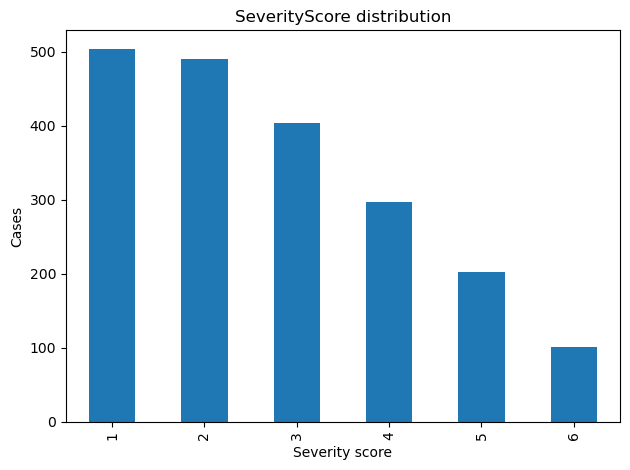

In [9]:
ax = target_counts.plot(kind='bar', title='SeverityScore distribution')
ax.set_xlabel('Severity score')
ax.set_ylabel('Cases')
plt.tight_layout()
plt.show()

**2.Duplicates and Missing values**

In [12]:
#Before dropping duplicates, the number of rows and columns are
print('The original number of rows and columns are ',train_df.shape)

The original number of rows and columns are  (2000, 46)


In [13]:
#Data Duplications
train_df = train_df.drop_duplicates()

print('the number of rows and columns after removing duplicates are', train_df.shape)

the number of rows and columns after removing duplicates are (2000, 46)


In [11]:
missing = (train_df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing[missing > 0].to_frame('missing_%').head(15)

,missing_%
FailureTypeSecondary,46.25
PrimaryVulnerability,25.25
VulnerabilityLevel,20.20
PhysicalImpactLevel,16.80
Jurisdiction,5.60
EvidenceStrength,2.90
ExpectedFinancialRedressGBP,2.80
RecoveryTimeMonths,2.70
OrganisationType,1.90
EmotionalImpactLevel,1.80


### Missing-data observation

Missing values are concentrated in four fields: `FailureTypeSecondary` (46.25%), `PrimaryVulnerability` (25.25%), `VulnerabilityLevel` (20.20%) and `PhysicalImpactLevel` (16.80%). All other fields shown have less than 6% missingness. The absence of a secondary failure or recorded vulnerability may be meaningful, so these values should not automatically be treated as data-entry errors. Their recording rules should be checked before selecting an imputation approach. Because vulnerability and physical impact are relevant to severity, model performance should also be examined for cases where these fields are missing.

**The missing-percentage above includes several fields that relate to the factors that affects severity though it does not show every factor directly.**

| Severity factor    | Column visible in the snapshot                                                                   |        Missing |
| ------------------ | ------------------------------------------------------------------------------------------------ | -------------: |
| Vulnerability      | `PrimaryVulnerability`, `VulnerabilityLevel`                                                     | 25.25%, 20.20% |
| Physical impact    | `PhysicalImpactLevel`                                                                            |         16.80% |
| Emotional impact   | `EmotionalImpactLevel`                                                                           |          1.80% |
| Financial impact   | `ExpectedFinancialRedressGBP`, `AdditionalCostsGBP`                                              |   2.80%, 1.80% |
| Duration of impact | `RecoveryTimeMonths` — a possible proxy, not necessarily the full duration                       |          2.70% |
| Service failures   | `FailureTypeSecondary` identifies a type of failure; it does **not** give the number of failures |         46.25% |


## Schema and leakage review

`CaseReference` is an identifier and is excluded from modelling. The deployable model also removes `InvestigationRoute`, `OmbudsmanInvestigationRequired`, `PredictedRemedyBand`, and `ExpectedFinancialRedressGBP` because they plausibly occur downstream of the decision being automated.